# 03 — Popularity Modeling

**Spotify Content Performance Analytics** — Phase 3 interpretable modeling layer.

## 1. Analytical question

> How much variation in `popularity_score` is associated with observable
> track/content/context characteristics, and how much additional predictive
> power appears when `artist_1_pop` is included?

**This is an observational dataset. No causal claims are made anywhere in
this notebook.** The goal is a defensible analytical comparison between a
content/context model (Model A) and a content/context + artist-popularity
model (Model B) — not a flashy model or maximum R².

Phase 2 (data foundation, cleaning, SQL layer) is frozen and unmodified by
this notebook; it only reads the already-built primary/sensitivity Parquet
files.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from src import modeling as M

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
FIGURES_DIR = "../figures"

## 2. Modeling sample

Built from the PRIMARY analytical dataset (Phase 2) via
`src/modeling.build_modeling_frame()`. Never modifies the frozen Phase 2
pipeline — only reads its Parquet output.

In [2]:
primary = pd.read_parquet("../data/processed/primary.parquet")
modeling_df, sample_notes = M.build_modeling_frame(primary)
sample_notes

{'input_rows': 277937,
 'rows_dropped_missing_release_decade': 4,
 'tempo_values_treated_as_missing': 90,
 'rows_with_unknown_genre': 167547,
 'output_rows': 277933,
 'rows_missing_artist_1': 19}

**Sample construction notes:**
- 4 rows with unknown `release_decade_clean` are dropped from the MODELING
  sample only (they remain in the primary analytical dataset untouched).
- 90 rows with `tempo == 0` are treated as missing (Phase 2 policy) and
  median-imputed inside the pipeline, fit on training data only.
- 167,547 rows (60.3%) have no observed primary genre and are coded as an
  explicit `"Unknown"` category, not imputed or dropped — if genre
  availability itself carries information (Phase 2 established that it
  does), that should show up as `Unknown`'s own coefficient.
- 19 rows have a missing `artist_1`; each gets its own synthetic group id
  for splitting purposes (see §4) rather than being lumped together.

## 3. Feature definitions

**Target:** `popularity_score` (0–100). Never included as a feature.
`popularity`, `popularity_tier`, and `is_high_popularity` are excluded from
every model because they are derived directly (in `popularity`'s case,
*exactly* — see Phase 2 §16) from the target — including them would be
reconstructing the target from its own recoding, not predicting it.

**Model A (content / context):**
| Feature | Type | What it represents | Caveat |
|---|---|---|---|
| `loudness` | continuous | Spotify-measured overall loudness (dB) | none beyond dataset scope |
| `valence` | continuous | Spotify's musical-positivity measure (0–1) | none beyond dataset scope |
| `tempo` | continuous | Beats per minute | 90 zero-tempo rows treated as missing, imputed |
| `track_duration_minutes` | continuous | Derived from `duration_ms` | none |
| `album_type` | categorical | album / single / compilation | none beyond dataset scope |
| `artist_1_genre_1` (+ `Unknown`) | categorical | Primary genre, each observed genre its own level | genre availability is NOT random w.r.t. popularity (Phase 2 §15) |
| `release_decade_clean` | categorical | Release decade | **entangled with recency, survivorship, catalog composition — not a pure content attribute** (see README) |

**Model B = Model A + `artist_1_pop`.** `artist_1_pop` is conceptually very
close to the outcome — popular artists mechanically tend to have popular
tracks via correlated underlying algorithmic signals. Model B is a
**contextual/predictive comparison, not evidence of a causal artist-
popularity effect** — this is discussed explicitly throughout, especially
in §8 and §11.

Genre is **not** collapsed to top-N/Other: all 17 observed genres are used
as their own level, plus an explicit `Unknown` level (never merged into
another category) — the full categorical matrix (37 total encoded features
for Model B) is small enough relative to 277K rows that no dimensionality
reduction was needed.

## 4. Split design

**Primary design:** `GroupShuffleSplit` grouped on `artist_1`, so no artist
appears on both sides of the split. **Secondary design:** a conventional
reproducible random row split, reported for comparison, never used to
choose between designs.

**Known limitation carried through:** `artist_1` is not a perfect canonical
artist identifier in this extract. In particular, `"Various Artists"` is a
placeholder used for compilation tracks (14,840 rows, ~5.3% of the primary
dataset) rather than a genuine shared identity. This becomes directly
relevant in §9–§10 below.

In [3]:
category_levels = M.get_category_levels(modeling_df)
g_train_idx, g_test_idx = M.grouped_split(modeling_df)
r_train_idx, r_test_idx = M.random_split(modeling_df)

group_ids = M.make_group_ids(modeling_df["artist_1"])
train_groups = set(group_ids.iloc[g_train_idx])
test_groups = set(group_ids.iloc[g_test_idx])

print(f"Random seed: {M.RANDOM_SEED}, test_size: {M.TEST_SIZE}")
print(f"Grouped split -- train: {len(g_train_idx):,} rows, test: {len(g_test_idx):,} rows")
print(f"Unique artist groups -- train: {len(train_groups):,}, test: {len(test_groups):,}")
print(f"Artist groups appearing on BOTH sides (must be 0): {len(train_groups & test_groups)}")
print(f"Random split   -- train: {len(r_train_idx):,} rows, test: {len(r_test_idx):,} rows")
print()
print("Target distribution, grouped split:")
print(pd.DataFrame({
    "train": modeling_df.iloc[g_train_idx][M.TARGET].describe(),
    "test": modeling_df.iloc[g_test_idx][M.TARGET].describe(),
}))

Random seed: 42, test_size: 0.2
Grouped split -- train: 210,659 rows, test: 67,274 rows
Unique artist groups -- train: 72,240, test: 18,061
Artist groups appearing on BOTH sides (must be 0): 0
Random split   -- train: 222,346 rows, test: 55,587 rows

Target distribution, grouped split:
               train          test
count  210659.000000  67274.000000
mean       28.417404     25.854178
std        20.756388     21.088620
min         0.000000      0.000000
25%         9.000000      4.000000
50%        29.000000     26.000000
75%        44.000000     42.000000
max       100.000000     95.000000


## 5–7. Baseline, Model A, Model B

Baseline predicts the TRAINING-set mean for every test row. All three are
evaluated identically on RAW (unclipped) predictions — see §9 for the
bounded-target diagnostic.

In [4]:
baseline_g = M.run_baseline(modeling_df, g_train_idx, g_test_idx)
model_a_g = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_A, category_levels, g_train_idx, g_test_idx)
model_b_g = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_B, category_levels, g_train_idx, g_test_idx)

results_grouped = pd.DataFrame({
    "baseline": baseline_g["metrics"],
    "Model A": model_a_g["metrics"],
    "Model B": model_b_g["metrics"],
}).T
results_grouped

,n,r2,mae,rmse
baseline,67274.0,-0.014774,18.281850,21.243667
Model A,67274.0,0.146632,16.575826,19.481088
Model B,67274.0,0.088495,15.557857,20.133735


**Primary (grouped-split) result:** Model A explains meaningfully more
variance than the baseline (R² ≈ 0.147 vs ≈ -0.015). Model B's R² on this
split is *lower* than Model A's (≈ 0.088) — this is investigated in depth in
§9–§10 and is one of the most important findings in this notebook, not a
bug.

## 8. Grouped vs. random split comparison

The same three models, evaluated on the secondary random row split.

In [5]:
baseline_r = M.run_baseline(modeling_df, r_train_idx, r_test_idx)
model_a_r = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_A, category_levels, r_train_idx, r_test_idx)
model_b_r = M.run_model(modeling_df, M.CONTINUOUS_FEATURES_B, category_levels, r_train_idx, r_test_idx)

results_random = pd.DataFrame({
    "baseline": baseline_r["metrics"],
    "Model A": model_a_r["metrics"],
    "Model B": model_b_r["metrics"],
}).T
results_random

,n,r2,mae,rmse
baseline,55587.0,-0.000025,17.884354,20.903644
Model A,55587.0,0.115264,16.600511,19.661807
Model B,55587.0,0.275521,14.368688,17.792189


In [6]:
comparison = pd.DataFrame({
    "grouped_R2": [baseline_g["metrics"]["r2"], model_a_g["metrics"]["r2"], model_b_g["metrics"]["r2"]],
    "random_R2":  [baseline_r["metrics"]["r2"], model_a_r["metrics"]["r2"], model_b_r["metrics"]["r2"]],
}, index=["baseline", "Model A", "Model B"])
comparison["random_minus_grouped"] = comparison["random_R2"] - comparison["grouped_R2"]
comparison

,grouped_R2,random_R2,random_minus_grouped
baseline,-0.014774,-0.000025,0.014749
Model A,0.146632,0.115264,-0.031368
Model B,0.088495,0.275521,0.187026


**This is the central finding of this analysis.** Model A's R² is
fairly stable across split designs (0.147 grouped vs. 0.115 random — modest
difference, in the direction one would expect since a small amount of
same-content/same-era leakage is possible even without artist grouping).
**Model B's R² swings dramatically: 0.088 on the grouped split vs. 0.276 on
the random split — a difference of +0.19, more than 3x its grouped-split
value.** Under the random split, the *same artist* can appear in both train
and test, so the model can partially learn "this exact `artist_1_pop` value
→ this artist's typical popularity" rather than a generalizable relationship
— that inflated-looking gain evaporates, and reverses, when evaluated on
genuinely unseen artists. This is exactly the target-proximity / leakage
risk flagged for `artist_1_pop` in §3, made concrete and measurable rather
than asserted.

## 9. Bounded-prediction diagnostic

`popularity_score` is bounded [0, 100]; a linear model is not. Reported on
RAW, unclipped predictions (grouped split, the primary evaluation).

In [7]:
bounded_table = pd.DataFrame({
    "Model A": model_a_g["bounded"],
    "Model B": model_b_g["bounded"],
}).T
bounded_table

,n,min_prediction,max_prediction,n_below_0,pct_below_0,n_above_100,pct_above_100
Model A,67274.0,-17.842411,45.959744,10.0,0.015,0.0,0.0
Model B,67274.0,-24.851938,65.340593,13388.0,19.901,0.0,0.0


Model A rarely predicts outside [0, 100] (10 of 67,274 test rows, all
just below 0). **Model B produces an out-of-range prediction for ~19.9% of
the grouped test set — almost entirely below 0** — a substantial jump in
instability directly coinciding with the R² collapse in §8. §10 traces this
to a specific, identifiable cause rather than leaving it as an unexplained
symptom.

## 10. Residual / failure analysis

Focused on cuts that show a materially different error pattern, using
Model B's raw grouped-split predictions.

In [8]:
test_df = modeling_df.iloc[g_test_idx].reset_index(drop=True).copy()
test_df["y_true"] = model_b_g["y_test"]
test_df["y_pred"] = model_b_g["y_pred"]
test_df["abs_err"] = (test_df["y_true"] - test_df["y_pred"]).abs()
test_df["bias"] = test_df["y_pred"] - test_df["y_true"]

def tier(x):
    return "low" if x <= 33 else ("moderate" if x <= 66 else "high")
test_df["actual_tier"] = test_df["y_true"].apply(tier)

print("MAE by actual popularity tier:")
print(test_df.groupby("actual_tier")["abs_err"].agg(["mean", "count"]))

MAE by actual popularity tier:
                  mean  count
actual_tier                  
high         29.066826   1856
low          13.317366  41550
moderate     18.407687  23868


Error rises sharply with actual popularity: MAE ≈ 13.3 for low-tier
tracks vs. ≈ 29.1 for high-tier tracks — a linear model shrinks extreme
values toward the mean, so it systematically underpredicts genuinely
high-popularity tracks. This is a standard, expected limitation of linear
regression on a skewed target (Phase 2 established `popularity_score` is
right-skewed), not specific to Model B.

In [9]:
print("MAE / bias by album_type:")
print(test_df.groupby("album_type").agg(mae=("abs_err","mean"), bias=("bias","mean"), n=("bias","count")))

MAE / bias by album_type:
                   mae       bias      n
album_type                              
album        14.109270  -0.479273  32388
compilation  20.528751 -18.715441  16059
single       13.809796  -0.609372  18827


**`compilation` stands out sharply:** MAE ≈ 20.5 (vs. ≈ 14 for album/
single) and a mean bias of **-18.7** (predictions ~19 points too high on
average). This is investigated directly in §11 — it traces to the same
cause as the grouped-split R² collapse in §8.

In [10]:
test_df["genre_known"] = test_df["artist_1_genre_1_filled"] != "Unknown"
print("MAE / bias, known vs. Unknown genre:")
print(test_df.groupby("genre_known").agg(mae=("abs_err","mean"), bias=("bias","mean"), n=("bias","count")))

MAE / bias, known vs. Unknown genre:
                   mae      bias      n
genre_known                            
False        15.695108 -6.726537  46195
True         15.257069 -0.797677  21079


Tracks with `Unknown` genre show a small systematic overprediction
bias (-6.7) vs. known-genre tracks (-0.8) — consistent with Phase 2's
finding that missing-genre tracks skew toward lower actual popularity than
the model, using only what it has, fully captures.

## 11. Artist-popularity diagnostic

Bucketing tracks by how many observations their `artist_1` has **in this
dataset** (not necessarily how many Spotify used to compute the external
`artist_1_pop` measure — that correspondence is unknown and not assumed).

In [11]:
track_counts = modeling_df["artist_1"].value_counts()
modeling_df["artist_freq_bucket"] = modeling_df["artist_1"].map(track_counts).pipe(M.artist_frequency_bucket)

bucket_test = modeling_df.iloc[g_test_idx].reset_index(drop=True).copy()
bucket_test["y_true"] = model_b_g["y_test"]
bucket_test["pred_a"] = model_a_g["y_pred"]
bucket_test["pred_b"] = model_b_g["y_pred"]

def bucket_r2(g, pred_col):
    ss_res = ((g["y_true"] - g[pred_col]) ** 2).sum()
    ss_tot = ((g["y_true"] - g["y_true"].mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

rows = []
for name, g in bucket_test.groupby("artist_freq_bucket", observed=True):
    rows.append({
        "bucket": name, "n": len(g),
        "r2_A": bucket_r2(g, "pred_a"), "r2_B": bucket_r2(g, "pred_b"),
        "mae_A": (g["y_true"]-g["pred_a"]).abs().mean(),
        "mae_B": (g["y_true"]-g["pred_b"]).abs().mean(),
    })
bucket_stats = pd.DataFrame(rows).set_index("bucket").loc[M.ARTIST_FREQUENCY_LABELS]
bucket_stats

,n,r2_A,r2_B,mae_A,mae_B
bucket,,,,,
1,11517,0.098039,0.343974,15.723537,12.933646
2,4954,0.070044,0.288329,15.509454,13.263416
3-5,8446,0.068220,0.271339,16.095398,13.861084
6-20,14039,0.109972,0.279174,16.885904,14.555867
21-100,12014,0.136072,0.331563,18.202506,14.991971
100+,16297,0.115815,-0.856228,16.289820,20.273048


Model B underperforms Model A specifically and severely in the
**"100+"** bucket (R² = -0.86 vs. 0.12 for Model A) — everywhere else Model
B is comparable to or better than Model A. This pattern, not a uniform
degradation, is why the aggregate result in §7–§8 looked the way it did.

In [12]:
va_mask = (modeling_df.iloc[g_test_idx]["artist_1"].reset_index(drop=True) == "Various Artists").to_numpy()
va_share = va_mask.mean()
print(f'"Various Artists" share of the grouped test set: {va_share*100:.1f}%')
print(f'"Various Artists" artist_1_pop values (should be a single constant): '
      f'{modeling_df.loc[modeling_df["artist_1"]=="Various Artists", "artist_1_pop"].nunique()} unique value(s), '
      f'= {modeling_df.loc[modeling_df["artist_1"]=="Various Artists", "artist_1_pop"].iloc[0]}')
print(f'"Various Artists" actual popularity_score: mean={modeling_df.loc[modeling_df["artist_1"]=="Various Artists", M.TARGET].mean():.1f}, '
      f'std={modeling_df.loc[modeling_df["artist_1"]=="Various Artists", M.TARGET].std():.1f}, '
      f'max={modeling_df.loc[modeling_df["artist_1"]=="Various Artists", M.TARGET].max()}')

r2_a_excl = M.evaluate_predictions(model_a_g["y_test"][~va_mask], model_a_g["y_pred"][~va_mask])["r2"]
r2_b_excl = M.evaluate_predictions(model_b_g["y_test"][~va_mask], model_b_g["y_pred"][~va_mask])["r2"]
print(f"\nModel A grouped R2: {model_a_g['metrics']['r2']:.4f} (full test) -> {r2_a_excl:.4f} (excluding 'Various Artists')")
print(f"Model B grouped R2: {model_b_g['metrics']['r2']:.4f} (full test) -> {r2_b_excl:.4f} (excluding 'Various Artists')")

"Various Artists" share of the grouped test set: 22.1%
"Various Artists" artist_1_pop values (should be a single constant): 1 unique value(s), = 0.0
"Various Artists" actual popularity_score: mean=16.2, std=18.6, max=81.0

Model A grouped R2: 0.1466 (full test) -> 0.1126 (excluding 'Various Artists')
Model B grouped R2: 0.0885 (full test) -> 0.3132 (excluding 'Various Artists')


**A directly verified, concrete mechanism, not a hypothesis:**
`"Various Artists"` — a placeholder for compilation tracks, not a real
artist — has a *constant* `artist_1_pop = 0.0` for all 14,840 of its rows,
despite those tracks having real, substantially varying actual popularity
(mean ≈ 16, up to 81). In this particular grouped split, the entire group
happened to land in the test set (a consequence of it being one unusually
large group relative to typical `artist_1` group sizes, combined with the
random partition — not guaranteed to recur under a different seed). Model
B, having never seen this placeholder value's relationship to popularity in
training, applies its learned coefficient uniformly to a highly
heterogeneous group — producing systematically poor, biased-high
predictions and collapsing the aggregate grouped-split R² for Model B.
Excluding just this one `artist_1` value from evaluation **reverses the
headline comparison**: Model B outperforms Model A substantially once this
placeholder is excluded (R² ≈ 0.31 vs. ≈ 0.11).

**What this does and does not show:** it does NOT prove `artist_1_pop` is
generally a strong, generalizable predictor once this artifact is removed —
that would need re-evaluation across many random seeds/splits to be a firm
claim, which is out of scope here. What it DOES show, concretely and
verifiably: (1) the raw §7/§8 primary-split headline result is highly
sensitive to how one large non-artist placeholder group happens to fall in
a single train/test partition, and (2) this is a direct, confirmed instance
of the documented limitation that `artist_1` is not a perfect canonical
identifier in this extract — not merely a theoretical caveat. The
strongest, split-seed-independent evidence about Model B remains the
grouped-vs-random comparison in §8: even setting the "Various Artists"
artifact aside, that comparison shows part of Model B's apparent gain is
attributable to same-artist leakage rather than to genuinely generalizable
information about track-level popularity.

## Coefficient interpretation

Continuous and categorical coefficients are reported separately, per the
project's coefficient-interpretation policy — standardized continuous
coefficients are not comparable to one-hot dummy coefficients on the same
scale, so they are never combined into one ranking.

In [13]:
feature_names = M.get_feature_names(model_b_g["pipeline"])
coefs = model_b_g["pipeline"].named_steps["regressor"].coef_

continuous_coefs = pd.Series(
    coefs[:len(M.CONTINUOUS_FEATURES_B)],
    index=[c.replace("num__", "") for c in feature_names[:len(M.CONTINUOUS_FEATURES_B)]],
    name="standardized_coefficient",
).sort_values()
continuous_coefs

track_duration_minutes   -0.757808
tempo                    -0.200887
valence                   0.386750
loudness                  0.430609
artist_1_pop              9.978311
Name: standardized_coefficient, dtype: float64

**Interpretation (Model B, standardized continuous features, grouped
split):** all are per-one-standard-deviation changes. `loudness` and
`artist_1_pop` have the largest positive associations; `track_duration_minutes`
has the largest negative association. Per the module docstring and README,
`artist_1_pop`'s coefficient here is descriptive/associational only — see
§8 and §11 for why it is not treated as robust, generalizable signal.

In [14]:
categorical_coefs = pd.Series(
    coefs[len(M.CONTINUOUS_FEATURES_B):],
    index=feature_names[len(M.CONTINUOUS_FEATURES_B):],
).sort_values()
print("Top 5 positive categorical coefficients (vs. documented reference categories):")
print(categorical_coefs.tail(5))
print("\nTop 5 negative categorical coefficients:")
print(categorical_coefs.head(5))
print("\nReference categories (dropped, coefficient = 0 by construction):", M.CATEGORY_REFERENCES)

Top 5 positive categorical coefficients (vs. documented reference categories):
cat__release_decade_clean_1980      4.061152
cat__artist_1_genre_1_filled_r&b    4.227303
cat__release_decade_clean_1970      4.565571
cat__release_decade_clean_2020      8.180339
cat__release_decade_clean_1940      8.630512
dtype: float64

Top 5 negative categorical coefficients:
cat__artist_1_genre_1_filled_classical   -7.627609
cat__album_type_compilation              -7.022570
cat__release_decade_clean_1910           -5.890989
cat__release_decade_clean_1920           -4.049032
cat__artist_1_genre_1_filled_blues       -2.820558
dtype: float64

Reference categories (dropped, coefficient = 0 by construction): {'album_type': 'album', 'artist_1_genre_1_filled': 'Unknown', 'release_decade_clean': '2010'}


## Reduced inferential specification (statsmodels)

A small, reduced specification (standardized Model-A continuous features +
`album_type` only — no genre or decade dummies, to keep this table compact
and avoid fitting an unnecessarily large inferential model on 278K rows) is
fit with `statsmodels` for p-values/confidence intervals, on the grouped
TRAINING split only.

In [15]:
cont_cols = M.CONTINUOUS_FEATURES_A
X_cont = modeling_df.iloc[g_train_idx][cont_cols].copy()
X_cont["tempo"] = X_cont["tempo"].fillna(X_cont["tempo"].median())
scaler = StandardScaler().fit(X_cont)
X_cont_scaled = pd.DataFrame(scaler.transform(X_cont), columns=cont_cols, index=X_cont.index)

album_dummies = pd.get_dummies(modeling_df.iloc[g_train_idx]["album_type"], prefix="album")
album_dummies = album_dummies.drop(columns=["album_album"])  # reference = album (largest group)

X = sm.add_constant(pd.concat([X_cont_scaled, album_dummies], axis=1).astype(float))
y = modeling_df.iloc[g_train_idx][M.TARGET].astype(float)

reduced_ols = sm.OLS(y, X).fit()
reduced_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       popularity_score   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     1038.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:20:30   Log-Likelihood:            -9.3474e+05
No. Observations:              210659   AIC:                         1.869e+06
Df Residuals:                  210652   BIC:                         1.870e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     27.4947      0.057    480.967      0.000      27.383      27.607
loudness                   2.0653      0.050     41.400      0.000       1.968       2.163
valence                    0.1297      0.050      2.618      0.009       0.033       0.227
tempo                     -0.4530      0.046     -9.848      0.000      -0.543      -0.363
track_duration_minutes    -1.9806      0.045    -43.763      0.000      -2.069      -1.892
album_compilation         -4.8664      0.249    -19.556      0.000      -5.354      -4.379
album_single               3.0979      0.096     32.275      0.000       2.910       3.286
==============================================================================
Omnibus:                    37326.569   Durbin-Watson:                   0.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8477.473
Skew:                           0.131   Prob(JB):                         0.00
Kurtosis:                       2.053   Cond. No.                         6.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

All coefficients are significant at p<0.01 with a low condition
number (≈7, no multicollinearity concern). Directionally consistent with
the Model B standardized coefficients above: `loudness` positive,
`track_duration_minutes` negative, `single` positive vs. the `album`
reference, `compilation` negative vs. `album`. **Associational only — no
causal interpretation.**

## 12. Sensitivity dataset result

Same Model A / Model B specifications and grouped-split design, run on the
one-record-per-`(track, artist_1)` sensitivity dataset (Phase 2).

In [16]:
sensitivity = pd.read_parquet("../data/processed/sensitivity.parquet")
sens_df, sens_notes = M.build_modeling_frame(sensitivity)
sens_category_levels = M.get_category_levels(sens_df)
s_train_idx, s_test_idx = M.grouped_split(sens_df)

sens_a = M.run_model(sens_df, M.CONTINUOUS_FEATURES_A, sens_category_levels, s_train_idx, s_test_idx)
sens_b = M.run_model(sens_df, M.CONTINUOUS_FEATURES_B, sens_category_levels, s_train_idx, s_test_idx)

sensitivity_comparison = pd.DataFrame({
    "primary_Model_A": model_a_g["metrics"],
    "sensitivity_Model_A": sens_a["metrics"],
    "primary_Model_B": model_b_g["metrics"],
    "sensitivity_Model_B": sens_b["metrics"],
}).T
sensitivity_comparison

,n,r2,mae,rmse
primary_Model_A,67274.0,0.146632,16.575826,19.481088
sensitivity_Model_A,67242.0,0.146532,16.577094,19.482459
primary_Model_B,67274.0,0.088495,15.557857,20.133735
sensitivity_Model_B,67242.0,0.088466,15.557952,20.134306


**Differences are trivial** (R² differs by < 0.001 for both models,
MAE/RMSE differ by < 0.01) — consistent with Phase 2's finding that the
primary and sensitivity datasets are nearly identical in every headline
respect. No substantive modeling conclusion in this notebook changes
depending on which dataset was used.

## Figures

Four figures, saved to `figures/`.

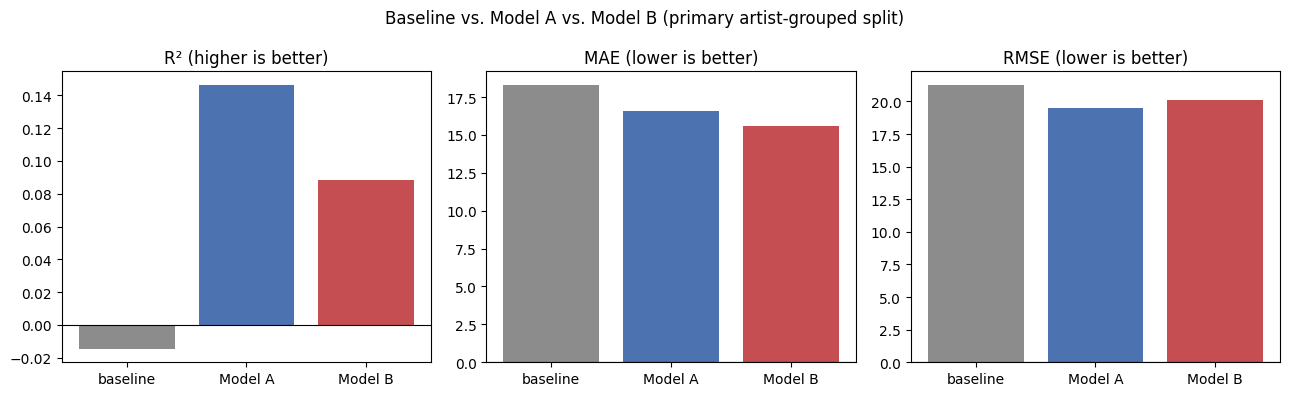

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics_names = ["r2", "mae", "rmse"]
titles = ["R² (higher is better)", "MAE (lower is better)", "RMSE (lower is better)"]
models_order = ["baseline", "Model A", "Model B"]
colors = ["#8C8C8C", "#4C72B0", "#C44E52"]
for ax, metric, title in zip(axes, metrics_names, titles):
    values = [results_grouped.loc[m, metric] for m in models_order]
    ax.bar(models_order, values, color=colors)
    ax.set_title(title)
    ax.axhline(0, color="black", linewidth=0.8)
fig.suptitle("Baseline vs. Model A vs. Model B (primary artist-grouped split)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_model_comparison_grouped_split.png", dpi=150)
plt.show()

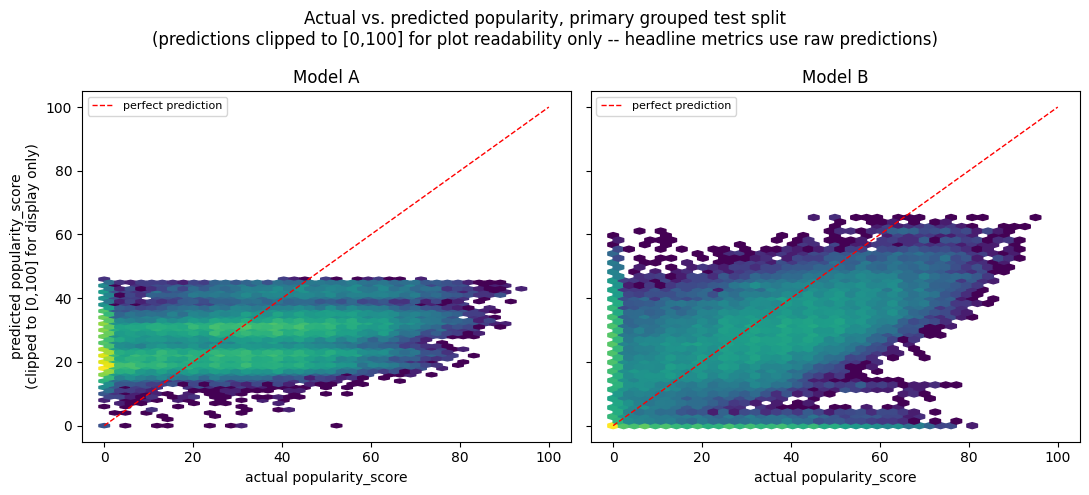

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, res, name in zip(axes, [model_a_g, model_b_g], ["Model A", "Model B"]):
    y_true = res["y_test"]
    y_pred_clipped = M.clip_predictions(res["y_pred"])
    ax.hexbin(y_true, y_pred_clipped, gridsize=40, cmap="viridis", mincnt=1, bins="log")
    ax.plot([0, 100], [0, 100], color="red", linewidth=1, linestyle="--", label="perfect prediction")
    ax.set_xlabel("actual popularity_score")
    ax.set_title(name)
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("predicted popularity_score\n(clipped to [0,100] for display only)")
fig.suptitle("Actual vs. predicted popularity, primary grouped test split\n(predictions clipped to [0,100] for plot readability only -- headline metrics use raw predictions)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_actual_vs_predicted.png", dpi=150)
plt.show()

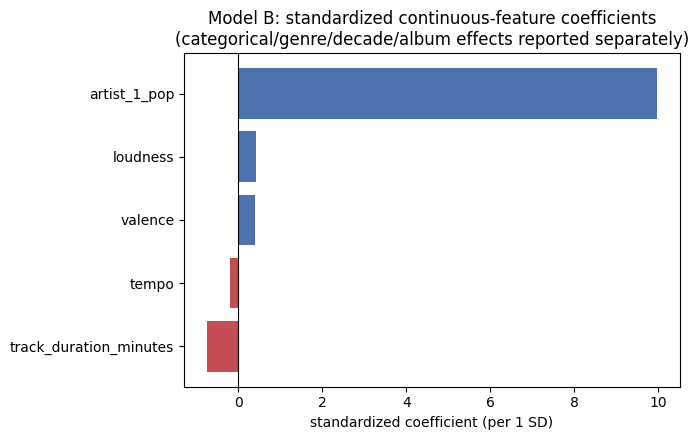

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_coefs = continuous_coefs.sort_values()
colors_c = ["#C44E52" if v < 0 else "#4C72B0" for v in plot_coefs.values]
ax.barh(plot_coefs.index, plot_coefs.values, color=colors_c)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("standardized coefficient (per 1 SD)")
ax.set_title("Model B: standardized continuous-feature coefficients\n(categorical/genre/decade/album effects reported separately)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_standardized_coefficients.png", dpi=150)
plt.show()

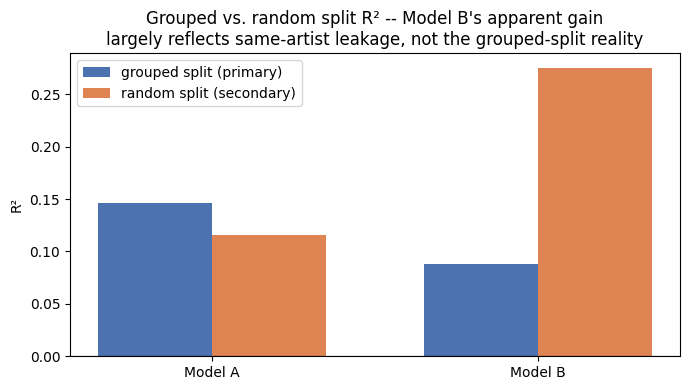

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
width = 0.35
grouped_vals = [model_a_g["metrics"]["r2"], model_b_g["metrics"]["r2"]]
random_vals = [model_a_r["metrics"]["r2"], model_b_r["metrics"]["r2"]]
ax.bar(x - width/2, grouped_vals, width, label="grouped split (primary)", color="#4C72B0")
ax.bar(x + width/2, random_vals, width, label="random split (secondary)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(["Model A", "Model B"])
ax.set_ylabel("R²")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Grouped vs. random split R² -- Model B's apparent gain\nlargely reflects same-artist leakage, not the grouped-split reality")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_grouped_vs_random_split.png", dpi=150)
plt.show()

## 13. Limitations

- **Observational data; no causal claims.** Every association reported here
  is descriptive, evaluated on held-out data, and stops short of causal
  language.
- **`artist_1_pop` target proximity.** Model B's evaluation is highly
  sensitive to how large, non-canonical `artist_1` groups (esp. "Various
  Artists") happen to fall in a given split — demonstrated concretely in
  §11, not just asserted.
- **`artist_1` is not a perfect canonical artist identifier** in this
  extract (may contain concatenated collaborator names; "Various Artists"
  is a placeholder, not a real artist) — the grouped split reduces but does
  not guarantee artist-level isolation.
- **Linear model, bounded target.** ~19.9% of Model B's grouped-split
  predictions fall outside [0, 100] — a real limitation of an unconstrained
  linear model on a bounded outcome, reported plainly rather than clipped
  away in the headline metrics.
- **Genre availability is not random** (Phase 2 §15) — the `Unknown` genre
  level's coefficient absorbs some of this selection pattern rather than
  cleanly separating "no genre" from "lower popularity for other reasons."
- **Release decade is entangled with recency/survivorship/catalog
  composition**, not a pure content attribute (see README).
- **Sampling frame and collection time remain unverified** (Phase 2) —
  every finding here is scoped to "tracks in this dataset."
- Model performance is modest (R² ≈ 0.11–0.15 for Model A across splits) —
  this is reported as a legitimate, honest result, not minimized.

## 14. Conclusions

- Model A (content/context only) explains a modest but real share of
  popularity variation relative to the training-mean baseline, and its
  performance is fairly stable across the grouped and random split designs.
- Model B (+ `artist_1_pop`) shows a split-design-dependent and, in this
  particular grouped split, largely artifact-driven result: its headline
  grouped-split R² is *lower* than Model A's, driven heavily by one
  large non-canonical `artist_1` group ("Various Artists") with a constant,
  uninformative `artist_1_pop` value; excluding that one group reverses the
  comparison. Under the random split (same-artist leakage possible), Model
  B looks substantially better — a gap that itself is evidence of target
  proximity / leakage risk, not evidence of genuine incremental predictive
  power.
- **The single strongest, most robust finding of this analysis is the
  grouped-vs-random split gap for Model B (§8), not either model's absolute
  R².** It directly demonstrates why `artist_1_pop` cannot be treated as a
  clean, independent predictor of track popularity in this dataset.
- No claim is made that content/context characteristics, or artist
  popularity, *cause* track popularity — only that they are associated with
  it, to the degree, and with the caveats, quantified above.